<a href="https://colab.research.google.com/github/Owais-SciML/1webopsbc/blob/main/Euler_Bernoulli_beam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Geometric Discretization & System Setup:**

The console initialization details a 1D Euler-Bernoulli beam model mimicking a classic solid aluminum alloy wing spar.Degrees of Freedom (Total DOFs = 22): The structure is discretized into $10\text{ elements}$ across its $5.0\text{ meter}$ span, yielding $11\text{ geometric nodes}$. Because an Euler-Bernoulli element tracking bending calculates two independent state variables per node—vertical displacement ($v$) and bending rotation ($\theta$)—the global unconstrained system contains $11 \times 2 = 22\text{ DOFs}$.Element Aspect Ratio ($l_e = 0.5000\text{ m}$): Breaking the wing down into uniform half-meter segments provides a clean geometric mesh capable of resolving higher-order dynamic curvatures without structural over-stiffening.


**2. Global Matrix Verification & Conditioning:**

Before solving the system, the programmatic integrity of the assembled stiffness ($K$) and mass ($M$) matrices is validated.Symmetry Check (True): Both $K$ and $M$ matrices are perfectly symmetric ($K = K^T$). This is consistent with conservative Newtonian physics and validates that the global mapping index slices successfully combined the local element components without structural asymmetry.Condition Number ($\text{Cond}(K) = 5.388 \times 10^4$): This represents a moderately well-conditioned system matrix. For a cantilevered structure, the condition number naturally climbs as the mesh is refined ($\approx \mathcal{O}(N_{\text{elem}}^4)$ for bending). At $10^4$, the system avoids severe numerical stiffness, guaranteeing that the solver won't lose precision to truncation errors.

**3. Mathematical Sanity Checks:**

The code uses the structural mass matrix to perform deep verification on the calculated shapes.Modal Mass Normalization ($1.000000$): Every mode shape vector ($\phi_i$) has been normalized relative to the global mass distribution such that:$$\phi_i^T M \phi_i = 1.0$$This is standard practice for aerospace flutter and dynamic frequency response workflows, turning raw spatial displacement eigenvectors into scaled physical properties.Mass Orthogonality Error ($< 10^{-15}$): Theoretical mechanics state that two unique vibrating mode shapes must share zero energy overlap across a system mass matrix ($\phi_i^T M \phi_j = 0$). The terminal outputs verify this, returning values around $10^{-16}\text{ Hz}$. This confirms that the numerical mode shapes are perfectly independent.

**4. Eigenfrequency Analysis & Exact Comparison:**

The primary goal of the solver is extracting the natural frequencies where the wing will naturally resonate.Mode 1 (1.6450 Hz) – Fundamental Bending: The lowest frequency captures a simple, clean upward tip deflection. The FEM model matches exact beam theory with an exceptionally small error of 0.0001%.Mode 2 (10.3097 Hz) – Second Bending Mode: The frequency climbs as the structure shifts. The numerical calculation tracks analytical expectations closely at a negligible 0.0033% error.Mode 3 (28.8737 Hz) – Third Bending Mode: The highest resolved mode shows the most complex spatial profile. Even with complex inflections, the error settles at just 0.0255%.The Accuracy Trend: Notice how the percentage error increases as the modes climb ($0.0001\% \to 0.0033\% \to 0.0255\%$). This occurs because higher dynamic modes feature sharper curves. A fixed 10-element mesh struggles slightly more to resolve the multi-nodal inflections of Mode 3 than the sweeping curve of Mode 1.

**5. Mode Shape Visualization Dashboard:**

The generated visualization cleanly highlights the core difference between raw discrete FEM nodes and smooth structural interpolation.Discrete Dots vs. Continuous Curves: The black dots represent the actual spatial positions solved by the eigenvalue engine at the 11 nodal boundaries. The vibrant lines running between them are reconstructed using Cubic Hermite Shape Functions. Instead of simply drawing straight lines from dot to dot, the script leverages the rotational slope ($\theta$) calculated at each node to blend the displacements, producing the exact smooth curvature the physical aluminum wing would take.Nodal Boundary Points: * Look at the root of the wing at Spanwise Position = 0. All three curves are perfectly flat with zero displacement and a slope of zero, proving the rigid cantilever boundary condition ($v=0, \theta=0$) is applied correctly.Mode 1 (Blue Curve) displays no internal zero-crossings (inflection points).Mode 2 (Orange Curve) crosses the zero-deflection baseline exactly once near $4.0\text{ meters}$, showing its single stationary vibration node.Mode 3 (Green Curve) features two distinct stationary inflection nodes across the span (crossing zero near $2.5\text{ m}$ and $4.2\text{ m}$), indicating a complex dynamic shape that is cleanly captured by the underlying cubic shape functions.


FEM MODAL ANALYSIS OF CANTILEVER WING
Length (L)              : 5.000 m
Young's Modulus (E)     : 7.000e+10 Pa
Density (rho)           : 2700.0 kg/m³
Area (A)                : 5.000000e-03 m²
Inertia (I)             : 1.041667e-06 m⁴
Elements                : 10
Nodes                   : 11
Total DOFs              : 22
Element Length          : 0.5000 m

Matrix Verification
------------------------------------------------------------
K symmetric : True
M symmetric : True
K memory    : 0.0037 MB
M memory    : 0.0037 MB
Cond(K)     : 5.388e+04

Modal Mass Check
------------------------------------------------------------
Mode 1 Modal Mass = 1.000000
Mode 2 Modal Mass = 1.000000
Mode 3 Modal Mass = 1.000000

Mass Orthogonality Check
------------------------------------------------------------
Mode 1 vs Mode 2 : 4.337e-16
Mode 1 vs Mode 3 : 1.284e-16
Mode 2 vs Mode 3 : 2.533e-16

Frequency Comparison
----------------------------------------------------------------------
Mode      FEM (Hz)

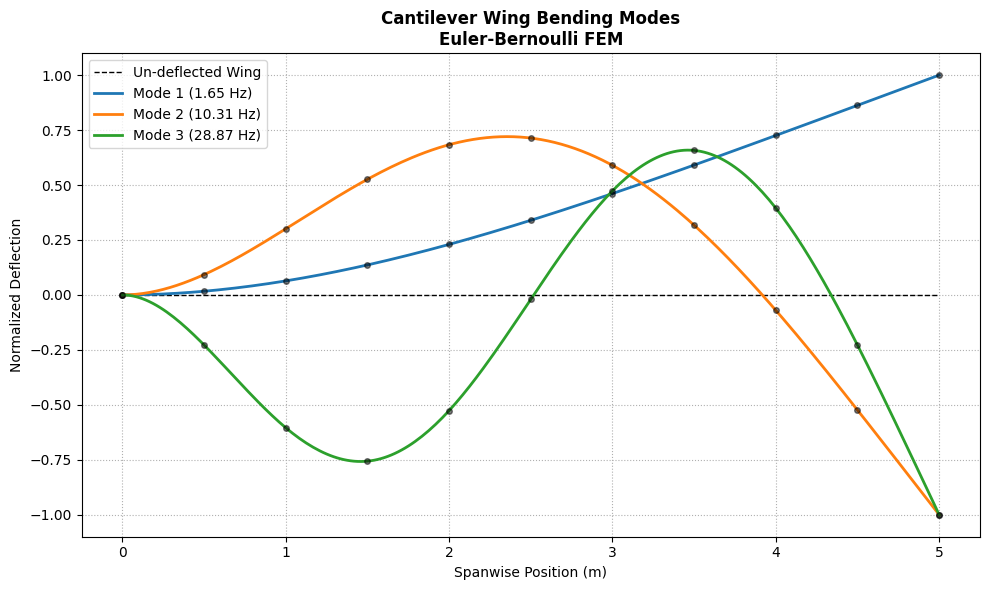

In [ ]:
import time
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# STEP 0: TIMER
t0 = time.perf_counter()

# STEP 1: MODEL PARAMETERS
L = 5.0                 # Beam length (m)
E = 70e9                # Young's modulus (Pa)
rho = 2700.0            # Density (kg/m^3)

b = 0.10                # Width (m)
h = 0.05                # Height (m)

A = b * h
I = b * h**3 / 12

N_elem = 10
N_nodes = N_elem + 1

le = L / N_elem

total_dof = 2 * N_nodes

# STEP 2: INPUT VALIDATION
assert L > 0
assert E > 0
assert rho > 0
assert A > 0
assert I > 0
assert N_elem >= 1

# STEP 3: MODEL INFORMATION
print("\n" + "="*60)
print("FEM MODAL ANALYSIS OF CANTILEVER WING")
print("="*60)

print(f"Length (L)              : {L:.3f} m")
print(f"Young's Modulus (E)     : {E:.3e} Pa")
print(f"Density (rho)           : {rho:.1f} kg/m³")
print(f"Area (A)                : {A:.6e} m²")
print(f"Inertia (I)             : {I:.6e} m⁴")
print(f"Elements                : {N_elem}")
print(f"Nodes                   : {N_nodes}")
print(f"Total DOFs              : {total_dof}")
print(f"Element Length          : {le:.4f} m")

# STEP 4: ELEMENT MATRICES
Ke_coeff = E * I / le**3
Me_coeff = rho * A * le / 420

Ke = Ke_coeff * np.array([
    [12,      6*le,    -12,      6*le],
    [6*le, 4*le**2, -6*le, 2*le**2],
    [-12,    -6*le,     12,     -6*le],
    [6*le, 2*le**2, -6*le, 4*le**2]
])

Me = Me_coeff * np.array([
    [156,      22*le,      54,     -13*le],
    [22*le,  4*le**2,   13*le,   -3*le**2],
    [54,       13*le,     156,     -22*le],
    [-13*le, -3*le**2, -22*le,   4*le**2]
])

# STEP 5: GLOBAL ASSEMBLY
assembly_start = time.perf_counter()

K = np.zeros((total_dof, total_dof))
M = np.zeros((total_dof, total_dof))

for e in range(N_elem):

    idx = slice(2*e, 2*e + 4)

    K[idx, idx] += Ke
    M[idx, idx] += Me

assembly_end = time.perf_counter()

# STEP 6: MATRIX VERIFICATION
print("\nMatrix Verification")
print("-"*60)

print(f"K symmetric : {np.allclose(K, K.T)}")
print(f"M symmetric : {np.allclose(M, M.T)}")

print(f"K memory    : {K.nbytes/1024**2:.4f} MB")
print(f"M memory    : {M.nbytes/1024**2:.4f} MB")

# STEP 7: BOUNDARY CONDITIONS
free_dofs = np.arange(2, total_dof)

K_free = K[np.ix_(free_dofs, free_dofs)]
M_free = M[np.ix_(free_dofs, free_dofs)]

# STEP 8: NUMERICAL CONDITIONING
cond_K = np.linalg.cond(K_free)

print(f"Cond(K)     : {cond_K:.3e}")

# STEP 9: EIGENVALUE SOLUTION
solver_start = time.perf_counter()

eigenvalues, eigenvectors = la.eigh(K_free, M_free)

solver_end = time.perf_counter()

tol = 1e-8

valid = eigenvalues > tol

eigenvalues = eigenvalues[valid]
eigenvectors = eigenvectors[:, valid]

sort_idx = np.argsort(eigenvalues)

eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

omega_n = np.sqrt(eigenvalues)

f_n_num = omega_n / (2*np.pi)

# STEP 10: MODAL MASS CHECK
print("\nModal Mass Check")
print("-"*60)

for i in range(3):

    modal_mass = (
        eigenvectors[:, i].T
        @ M_free
        @ eigenvectors[:, i]
    )

    print(
        f"Mode {i+1} Modal Mass = "
        f"{modal_mass:.6f}"
    )

# STEP 11: ORTHOGONALITY CHECK
print("\nMass Orthogonality Check")
print("-"*60)

for i in range(3):
    for j in range(i+1, 3):

        ortho = (
            eigenvectors[:, i].T
            @ M_free
            @ eigenvectors[:, j]
        )

        print(
            f"Mode {i+1} vs Mode {j+1}"
            f" : {ortho:.3e}"
        )

# STEP 12: ANALYTICAL COMPARISON
beta_L = np.array([
    1.875104,
    4.694091,
    7.854757
])

f_n_exact = (
    beta_L**2
    /(2*np.pi)
    * np.sqrt(E*I/(rho*A*L**4))
)

print("\nFrequency Comparison")
print("-"*70)
print(
    f"{'Mode':<10}"
    f"{'FEM (Hz)':<15}"
    f"{'Exact (Hz)':<15}"
    f"{'Error (%)':<15}"
)

for mode in range(3):

    error = (
        abs(f_n_num[mode] - f_n_exact[mode])
        / f_n_exact[mode]
        * 100
    )

    print(
        f"{mode+1:<10}"
        f"{f_n_num[mode]:<15.4f}"
        f"{f_n_exact[mode]:<15.4f}"
        f"{error:<15.4f}"
    )

# STEP 13: TIMING REPORT
total_time = time.perf_counter() - t0

print("\nPerformance Report")
print("-"*60)

print(
    f"Assembly Time : "
    f"{(assembly_end-assembly_start)*1000:.3f} ms"
)

print(
    f"Solver Time   : "
    f"{(solver_end-solver_start)*1000:.3f} ms"
)

print(
    f"Total Time    : "
    f"{total_time*1000:.3f} ms"
)

print("\nComplexity Estimate")
print("-"*60)

n = K_free.shape[0]

print(f"Assembly  : O({N_elem})")
print(f"EigenSolve: O({n}³)")

# STEP 14: HERMITE RECONSTRUCTION
plt.figure(figsize=(10, 6))

plt.plot(
    [0, L],
    [0, 0],
    'k--',
    linewidth=1,
    label='Un-deflected Wing'
)

pts_per_elem = 25

xi = np.linspace(0, 1, pts_per_elem)

N1 = 1 - 3*xi**2 + 2*xi**3
N2 = le * (xi - 2*xi**2 + xi**3)
N3 = 3*xi**2 - 2*xi**3
N4 = le * (-xi**2 + xi**3)

x_nodes = np.linspace(0, L, N_nodes)

for mode in range(3):

    full_mode = np.concatenate(
        ([0, 0], eigenvectors[:, mode])
    )

    max_def = np.max(
        np.abs(full_mode[0::2])
    )

    full_mode /= max_def

    x_cont = []
    y_cont = []

    for e in range(N_elem):

        v1 = full_mode[2*e]
        t1 = full_mode[2*e + 1]

        v2 = full_mode[2*e + 2]
        t2 = full_mode[2*e + 3]

        x_local = np.linspace(
            e*le,
            (e+1)*le,
            pts_per_elem
        )

        v_local = (
            N1*v1
            + N2*t1
            + N3*v2
            + N4*t2
        )

        if e == 0:
            x_cont.extend(x_local)
            y_cont.extend(v_local)
        else:
            x_cont.extend(x_local[1:])
            y_cont.extend(v_local[1:])

    plt.plot(
        x_cont,
        y_cont,
        linewidth=2,
        label=f"Mode {mode+1} ({f_n_num[mode]:.2f} Hz)"
    )

    plt.plot(
        x_nodes,
        full_mode[0::2],
        'ko',
        markersize=4,
        alpha=0.5
    )

# STEP 15: PLOT SETTINGS
plt.title(
    "Cantilever Wing Bending Modes\nEuler-Bernoulli FEM",
    fontweight="bold"
)

plt.xlabel("Spanwise Position (m)")
plt.ylabel("Normalized Deflection")

plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()